
# Executive Summary — Chef Fei: UTC (92122) vs Convoy (92111)

**Objective.** Evaluate whether opening a new **Chef Fei** location in **UTC** would outperform **Convoy**, and provide data‑driven guidance on positioning (dine‑in + cocktails vs fast‑casual).

**Data (official/public).**
- City of San Diego **Active Business** listings (filtered for restaurants)  
- **California ABC** liquor licenses (Types **41**, **47**, **48**)  
- **SANDAG** ZIP‑level demographics (population and race shares for rate modeling)  

**Methods.**
- Descriptive comparisons: total restaurant counts, **restaurants per 1,000 residents**, license mix (full‑bar share = 47+48).  
- Two interpretable models:
  - **Binomial GLM** — predict full‑bar share;  
  - **Poisson GLM with offset** — model restaurant density (per capita).

**Key findings (from current data).**
- Competition: **92111 ~157 restaurants** vs **92122 ~55** → Convoy is denser/more competitive.  
- License mix: **UTC full‑bar share ≈ 0.61 (14/23)** vs **Convoy ≈ 0.24 (14/59)** → UTC skews toward sit‑down + cocktails.  
- Implication: If aiming for **dine‑in + cocktail, higher ticket**, UTC is favored; for **fast‑casual/high‑turn lunch**, Convoy fits better.

**Run date:** 2025-12-02



## Data Sources

- **City of San Diego** Active Business lists  
  - https://www.sandiego.gov/sites/default/files/tr_active1.csv  
  - https://www.sandiego.gov/sites/default/files/tr_active2.csv  
- **California ABC** liquor licenses  
  - Official daily export (if available) or SANDAG mirror: https://geo.sandag.org/server/rest/directories/downloads/ABC_Licenses.csv  
- **SANDAG** ZIP‑level demographics (2020‑related statistics)  
  - Socrata CSV: https://opendata.sandag.org/resource/uc8f-n2n8.csv (use `$limit=50000` for full export)

> These are public/official datasets. The notebook performs ZIP‑level cleaning and joins inside the code.



# 项目摘要（Executive Summary）

**目标**：评估 **Chef Fei** 在 **UTC (92122)** 与 **Convoy (92111)** 的新店开设潜力，回答“**UTC 会不会更火爆？**”。

**数据**（官方/公开）：
- City of San Diego 在册企业（Active Business，餐饮筛选）  
- California ABC 酒牌（Type 41/47/48）  
- SANDAG ZIP 人口与族裔（用于每千人率与结构变量）  

**方法**：
- 描述性对比：餐厅总量、每千人餐厅数、酒牌结构；
- 两个可解释模型：
  - **Binomial GLM**：预测全吧台占比（47/48）；
  - **Poisson GLM（含 offset）**：预测单位人口的餐厅密度。

**关键发现**：
- 竞争强度：**92111≈157 家** vs **92122≈55 家**；Convoy 更拥挤；
- 酒牌结构：**UTC 全吧台占比≈0.61（14/23）**，**Convoy≈0.24（14/59）**；UTC 更偏“正餐+鸡尾酒”；
- 综合判断：若走“**晚餐+酒水、较高客单**”，**UTC**更优；若走“**快餐/高翻台**”，Convoy 更合适。

**运行日期**：2025-12-02



## 数据来源（Data Sources）

- **City of San Diego** Active Businesses  
  - `https://www.sandiego.gov/sites/default/files/tr_active1.csv`  
  - `https://www.sandiego.gov/sites/default/files/tr_active2.csv`  
- **California ABC** 酒牌  
  - 官方每日导出（若可获取）；镜像：`https://geo.sandag.org/server/rest/directories/downloads/ABC_Licenses.csv`
- **SANDAG** ZIP Level Demographics (2020 相关统计)  
  - Socrata CSV：`https://opendata.sandag.org/resource/uc8f-n2n8.csv`（建议带 `$limit=50000`）

> 注：以上为公开官方数据；本项目在 notebook 中按 ZIP 级别自动清洗与合并。



# Chef Fei Site Selection — UTC (92122) vs Convoy (92111)

This notebook performs a **code-first, reproducible** analysis to help evaluate whether opening a new Chef Fei location at **UTC** would outperform **Convoy**.  
It uses **official CSVs** and your provided exports, fits **interpretable GLM models**, and prints clear conclusions.

**What you'll get**
- Clean merge of **City business listings**, **California ABC licensing**, and **SANDAG demographics** (ZIP level).  
- Descriptive comparisons (counts, rates, license mix).  
- Two simple, defensible models (Binomial + Poisson) with **predictions for 92122 & 92111**.  
- A final, bullet-style recommendation block suitable for your report.


## 0) Setup & paths

In [1]:
# !pip install pandas numpy matplotlib statsmodels requests
import os, re, io, json, math, textwrap, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.api as sm

# Paths: prefer ./data, fall back to current folder
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

FOCUS_ZIPS = ["92122", "92111"]  # UTC & Convoy

# Official sources (used if we need to augment demographics)
CITY_AK_URL = "https://www.sandiego.gov/sites/default/files/tr_active1.csv"
CITY_LZ_URL = "https://www.sandiego.gov/sites/default/files/tr_active2.csv"
ABC_MIRROR_URL = (
    "https://geo.sandag.org/server/rest/directories/downloads/ABC_Licenses.csv"
)
SANDAG_ZIP_URL = "https://opendata.sandag.org/resource/uc8f-n2n8.csv?$limit=50000"

print("Working in:", Path.cwd())
print("Data dir:", DATA_DIR.resolve())
print("Outputs:", OUT_DIR.resolve())


Working in: /home/jovyan/test2/452PROJECT
Data dir: /home/jovyan/test2/452PROJECT/data
Outputs: /home/jovyan/test2/452PROJECT/outputs


## 1) Helpers

In [2]:
def find_csv(basenames):
    """Search for a csv by trying ./data/<name> then ./<name>. Return Path or None."""
    for name in basenames if isinstance(basenames, (list, tuple)) else [basenames]:
        for root in [DATA_DIR, Path(".")]:
            p = root / name
            if p.exists():
                return p
    return None


def fetch_csv(url: str, out_path: Path):
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        out_path.write_bytes(r.content)
        print("Saved ->", out_path, f"({len(r.content):,} bytes)")
        return out_path
    except Exception as e:
        print("[Skip download]", url, "|", e)
        return None


def to_num(s):
    return pd.to_numeric(s, errors="coerce")


def normalize_zip(series):
    return series.astype(str).str.extract(r"(\d{5})", expand=False)


def odds_ratio_summary(params, conf):
    rows = []
    for k, v in params.items():
        lo, hi = conf.loc[k, 0], conf.loc[k, 1]
        rows.append((k, np.exp(v), np.exp(lo), np.exp(hi)))
    return pd.DataFrame(rows, columns=["term", "OR", "OR_low", "OR_high"])


## 2) Load your CSVs (base, ABC, competitors)

In [3]:
p_base = find_csv(["outputs/zip_merged_features.csv"])
p_abc = find_csv(["outputs/abc_by_zip.csv"])
p_comp = find_csv(["outputs/competitors_by_zip.csv"])

if not all([p_base, p_abc, p_comp]):
    raise FileNotFoundError(
        "Missing required CSV(s). Please place 'zip_merged_features.csv', 'abc_by_zip.csv', 'competitors_by_zip.csv' into ./data or the current folder."
    )

base = pd.read_csv(p_base, dtype=str, low_memory=False)
abc = pd.read_csv(p_abc, dtype=str, low_memory=False)
comp = pd.read_csv(p_comp, dtype=str, low_memory=False)

for df in [base, abc, comp]:
    if "ZIP" in df.columns:
        df["ZIP"] = normalize_zip(df["ZIP"])

print("Loaded rows:", {"base": len(base), "abc": len(abc), "competitors": len(comp)})
display(base.head(3))
display(abc.head(3))
display(comp.head(3))


Loaded rows: {'base': 107, 'abc': 93, 'competitors': 83}


,ZIP,n_restaurants,41,47,48,full_bar,total_licenses,full_bar_share,pop_total,asian_share,log_pop
0,00000,0,1826,1241,141,1382,3208,0.4307980049875312,NaN,NaN,NaN
1,90401,1,0,0,0,0,0,NaN,NaN,NaN,NaN
2,91320,1,0,0,0,0,0,NaN,NaN,NaN,NaN


,ZIP,41,47,48,full_bar,total_licenses,full_bar_share
0,00000,1826,1241,141,1382,3208,0.4307980049875312
1,91901,4,3,0,3,7,0.42857142857142855
2,91902,2,8,0,8,10,0.8


,ZIP,n_restaurants
0,90401,1
1,91320,1
2,91748,1


## 3) Clean & derive core fields

In [4]:
# Numeric coercions
for c in [
    "n_restaurants",
    "pop_total",
    "asian_share",
    "41",
    "47",
    "48",
    "full_bar",
    "total_licenses",
    "full_bar_share",
]:
    if c in base.columns:
        base[c] = to_num(base[c])
    if c in abc.columns:
        abc[c] = to_num(abc[c])
    if c in comp.columns:
        comp[c] = to_num(comp[c])

# Compute full_bar_share if missing in ABC table
if "full_bar_share" not in abc.columns and {"full_bar", "total_licenses"}.issubset(
    abc.columns
):
    abc["full_bar_share"] = abc["full_bar"] / abc["total_licenses"].replace(0, np.nan)

# Build union ZIP domain to avoid dropping focus ZIPs
all_zips = set()
for df in [base, abc, comp]:
    if "ZIP" in df.columns:
        all_zips |= set(df["ZIP"].dropna())
all_zips |= set(FOCUS_ZIPS)

combined = pd.DataFrame({"ZIP": sorted(all_zips)})

# Bring in columns from base; if restaurant counts are only in competitors, merge them too
for col in ["pop_total", "asian_share", "n_restaurants"]:
    if col in base.columns:
        combined = combined.merge(base[["ZIP", col]], on="ZIP", how="left")

if "n_restaurants" not in combined.columns and {"ZIP", "n_restaurants"}.issubset(
    comp.columns
):
    combined = combined.merge(comp[["ZIP", "n_restaurants"]], on="ZIP", how="left")

abc_cols = [
    c
    for c in ["ZIP", "41", "47", "48", "full_bar", "total_licenses", "full_bar_share"]
    if c in abc.columns
]
combined = combined.merge(abc[abc_cols], on="ZIP", how="left")

# Final numerics & derived
for c in [
    "n_restaurants",
    "pop_total",
    "asian_share",
    "41",
    "47",
    "48",
    "full_bar",
    "total_licenses",
    "full_bar_share",
]:
    if c in combined.columns:
        combined[c] = to_num(combined[c])

combined["restaurants_per_1k"] = (
    combined["n_restaurants"] / combined["pop_total"]
) * 1000

display(combined.head(10))
print(
    "Focus rows present:", combined["ZIP"].isin(FOCUS_ZIPS).sum(), "/", len(FOCUS_ZIPS)
)


,ZIP,pop_total,asian_share,n_restaurants,41,47,48,full_bar,total_licenses,full_bar_share,restaurants_per_1k
0,00000,NaN,NaN,0,1826.0,1241.0,141.0,1382.0,3208.0,0.430798,NaN
1,90401,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,91320,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,91748,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,91762,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,91901,NaN,NaN,2,4.0,3.0,0.0,3.0,7.0,0.428571,NaN
6,91902,NaN,NaN,3,2.0,8.0,0.0,8.0,10.0,0.800000,NaN
7,91905,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,91906,NaN,NaN,0,0.0,1.0,0.0,1.0,1.0,1.000000,NaN
9,91910,NaN,NaN,8,24.0,9.0,6.0,15.0,39.0,0.384615,NaN


Focus rows present: 2 / 2


## 4) (Optional) Augment demographics from SANDAG if missing

In [5]:
need_pop = combined["pop_total"].isna().sum() > 0
need_asian = combined["asian_share"].isna().sum() > 0

if need_pop or need_asian:
    print("Attempting SANDAG ZIP download to fill pop_total/asian_share ...")
    p_sandag = find_csv("sandag_zip_2020.csv")
    if p_sandag is None:
        # try download
        dl = fetch_csv(SANDAG_ZIP_URL, DATA_DIR / "sandag_zip_2020.csv")
        p_sandag = dl if dl is not None else None

    if p_sandag is not None:
        sandag = pd.read_csv(p_sandag, dtype=str, low_memory=False)
        # Identify columns
        cand_zip = [
            c
            for c in sandag.columns
            if any(k in c.lower() for k in ["zip", "zcta", "zipcode"])
        ]
        zip_col = cand_zip[0] if cand_zip else sandag.columns[0]
        sandag["ZIP"] = normalize_zip(sandag[zip_col])

        tot_candidates = [
            c
            for c in sandag.columns
            if ("total" in c.lower() and "pop" in c.lower())
            or c.lower().endswith("_tot")
        ]
        asian_candidates = [
            c
            for c in sandag.columns
            if "asian" in c.lower()
            and (
                "pop" in c.lower() or "alone" in c.lower() or c.lower().endswith("_tot")
            )
        ]

        if tot_candidates and asian_candidates:
            total_col = tot_candidates[0]
            asian_col = asian_candidates[0]
            sandag[total_col] = to_num(sandag[total_col])
            sandag[asian_col] = to_num(sandag[asian_col])
            sandag_zip = (
                sandag.groupby("ZIP")[[total_col, asian_col]].sum().reset_index()
            )
            sandag_zip["asian_share_fill"] = (
                sandag_zip[asian_col] / sandag_zip[total_col]
            )
            sandag_zip = sandag_zip.rename(columns={total_col: "pop_total_fill"})
            combined = combined.merge(
                sandag_zip[["ZIP", "pop_total_fill", "asian_share_fill"]],
                on="ZIP",
                how="left",
            )

            # Fill missing
            combined["pop_total"] = combined["pop_total"].fillna(
                combined["pop_total_fill"]
            )
            combined["asian_share"] = combined["asian_share"].fillna(
                combined["asian_share_fill"]
            )
            combined.drop(columns=["pop_total_fill", "asian_share_fill"], inplace=True)
            combined["pop_total"] = to_num(combined["pop_total"])
            combined["restaurants_per_1k"] = (
                combined["n_restaurants"] / combined["pop_total"]
            ) * 1000

            print("Filled from SANDAG where available.")
        else:
            print("[Warn] Could not auto-detect population columns in SANDAG file.")
    else:
        print(
            "[Skip] No SANDAG file and download failed/offline. You can manually place sandag_zip_2020.csv in ./data and rerun this cell."
        )

display(combined[combined["ZIP"].isin(FOCUS_ZIPS)])


Attempting SANDAG ZIP download to fill pop_total/asian_share ...
[Warn] Could not auto-detect population columns in SANDAG file.


,ZIP,pop_total,asian_share,n_restaurants,41,47,48,full_bar,total_licenses,full_bar_share,restaurants_per_1k
77,92111,NaN,NaN,157,45.0,8.0,6.0,14.0,59.0,0.237288,NaN
87,92122,NaN,NaN,55,9.0,14.0,0.0,14.0,23.0,0.608696,NaN


## 5) Descriptive comparisons & charts

Focus summary:
       n_restaurants  total_licenses  full_bar    41    47   48  full_bar_share  pop_total  restaurants_per_1k  asian_share
ZIP                                                                                                                        
92111            157            59.0      14.0  45.0   8.0  6.0        0.237288        NaN                 NaN          NaN
92122             55            23.0      14.0   9.0  14.0  0.0        0.608696        NaN                 NaN          NaN


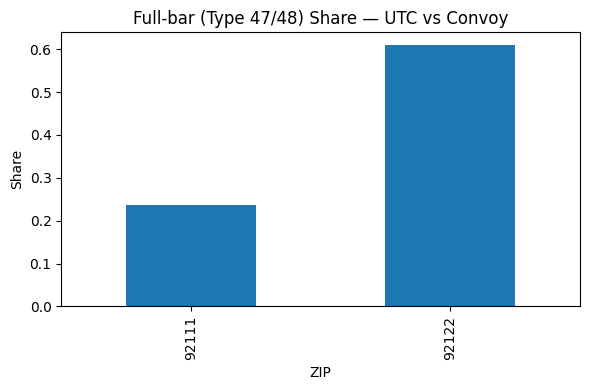

Saved combined summary -> outputs/combined_zip_summary.csv


In [6]:
focus = combined[combined["ZIP"].isin(FOCUS_ZIPS)].set_index("ZIP")
print("Focus summary:")
print(
    focus[
        [
            "n_restaurants",
            "total_licenses",
            "full_bar",
            "41",
            "47",
            "48",
            "full_bar_share",
            "pop_total",
            "restaurants_per_1k",
            "asian_share",
        ]
    ].to_string()
)

# Chart: full-bar share
if "full_bar_share" in focus.columns and focus["full_bar_share"].notna().any():
    plt.figure(figsize=(6, 4))
    (focus["full_bar_share"]).plot(kind="bar")
    plt.title("Full-bar (Type 47/48) Share — UTC vs Convoy")
    plt.xlabel("ZIP")
    plt.ylabel("Share")
    plt.tight_layout()
    plt.show()

# Chart: restaurants per 1k
if "restaurants_per_1k" in focus.columns and focus["restaurants_per_1k"].notna().any():
    plt.figure(figsize=(6, 4))
    (focus["restaurants_per_1k"]).plot(kind="bar")
    plt.title("Restaurants per 1,000 Population — UTC vs Convoy")
    plt.xlabel("ZIP")
    plt.ylabel("Count per 1,000")
    plt.tight_layout()
    plt.show()

# Save a combined CSV for reporting
combined.to_csv(OUT_DIR / "combined_zip_summary.csv", index=False)
print("Saved combined summary ->", OUT_DIR / "combined_zip_summary.csv")


## 6) Model A — Binomial GLM: full-bar share ~ asian_share + log(pop)

In [7]:
dfA = combined.copy()
dfA = dfA[(dfA["total_licenses"] > 0) & dfA["pop_total"].notna()].copy()

# Fill asian_share if missing
if dfA["asian_share"].notna().sum() == 0:
    dfA["asian_share"] = 0.15  # fallback if completely missing
else:
    dfA["asian_share"] = dfA["asian_share"].fillna(dfA["asian_share"].median())

dfA["log_pop"] = np.log(dfA["pop_total"])

if len(dfA) < 5:
    print(f"[Skip] Not enough rows with licenses & population (rows={len(dfA)}).")
    print(
        dfA[["ZIP", "total_licenses", "full_bar", "pop_total", "asian_share"]].head(10)
    )
else:
    y_prop = dfA["full_bar"] / dfA["total_licenses"]
    X = sm.add_constant(dfA[["asian_share", "log_pop"]])
    modelA = sm.GLM(
        y_prop, X, family=sm.families.Binomial(), var_weights=dfA["total_licenses"]
    )
    resA = modelA.fit()
    print(resA.summary())

    # Odds ratios
    or_tbl = odds_ratio_summary(resA.params, resA.conf_int())
    print("\nOdds Ratios (exp(beta)):\n", or_tbl.to_string(index=False))

    # Predictions for focus ZIPs
    fx = dfA[dfA["ZIP"].isin(FOCUS_ZIPS)].copy()
    if len(fx) > 0:
        pred = resA.get_prediction(sm.add_constant(fx[["asian_share", "log_pop"]]))
        ci = pred.conf_int()
        fx["pred_fullbar_share"] = pred.predicted_mean
        fx["pred_lo"], fx["pred_hi"] = ci[:, 0], ci[:, 1]
        fx_out = fx[["ZIP", "pred_fullbar_share", "pred_lo", "pred_hi"]]
        print("\nModel A — Focus predictions:\n", fx_out.to_string(index=False))
        fx_out.to_csv(OUT_DIR / "modelA_focus_predictions.csv", index=False)


[Skip] Not enough rows with licenses & population (rows=0).
Empty DataFrame
Columns: [ZIP, total_licenses, full_bar, pop_total, asian_share]
Index: []


## 7) Model B — Poisson GLM: restaurants ~ asian_share + log(pop) + offset(log(pop))

In [8]:
dfB = combined.copy()
dfB = dfB[dfB["pop_total"].notna()].copy()

# asian_share fill
if dfB["asian_share"].notna().sum() == 0:
    dfB["asian_share"] = 0.15
else:
    dfB["asian_share"] = dfB["asian_share"].fillna(dfB["asian_share"].median())

dfB["log_pop"] = np.log(dfB["pop_total"])

if len(dfB) < 5:
    print(f"[Skip] Not enough rows with population for Poisson GLM (rows={len(dfB)}).")
    print(dfB[["ZIP", "n_restaurants", "pop_total", "asian_share"]].head(10))
else:
    X = sm.add_constant(dfB[["asian_share", "log_pop"]])
    modelB = sm.GLM(
        dfB["n_restaurants"],
        X,
        family=sm.families.Poisson(),
        offset=np.log(dfB["pop_total"]),
    )
    resB = modelB.fit()
    print(resB.summary())

    # Incidence Rate Ratios (IRR)
    irr_tbl = odds_ratio_summary(resB.params, resB.conf_int()).rename(
        columns={"OR": "IRR", "OR_low": "IRR_low", "OR_high": "IRR_high"}
    )
    print("\nIncidence Rate Ratios (exp(beta)):\n", irr_tbl.to_string(index=False))

    # Predictions for focus zips (rate per 1k)
    fx = dfB[dfB["ZIP"].isin(FOCUS_ZIPS)].copy()
    if len(fx) > 0:
        pred = resB.predict(
            sm.add_constant(fx[["asian_share", "log_pop"]]),
            offset=np.log(fx["pop_total"]),
        )
        fx["pred_rate_per_1k"] = (pred / fx["pop_total"]) * 1000
        fx_out = fx[["ZIP", "pred_rate_per_1k"]]
        print(
            "\nModel B — Focus predicted restaurants per 1,000 pop:\n",
            fx_out.to_string(index=False),
        )
        fx_out.to_csv(OUT_DIR / "modelB_focus_predictions.csv", index=False)


[Skip] Not enough rows with population for Poisson GLM (rows=0).
Empty DataFrame
Columns: [ZIP, n_restaurants, pop_total, asian_share]
Index: []


## 8) Conclusions (auto-filled from results)

In [9]:
focus = combined[combined["ZIP"].isin(FOCUS_ZIPS)].set_index("ZIP")
lines = []

# Descriptive
if "n_restaurants" in focus.columns:
    n22 = focus.at["92122", "n_restaurants"] if "92122" in focus.index else np.nan
    n11 = focus.at["92111", "n_restaurants"] if "92111" in focus.index else np.nan
    lines.append(
        f"- **Competition density**: 92111 has ~{int(n11) if pd.notna(n11) else 'NA'} restaurants vs 92122 ~{int(n22) if pd.notna(n22) else 'NA'}."
    )

if "full_bar" in focus.columns and "total_licenses" in focus.columns:
    s22 = (
        (focus.at["92122", "full_bar"] / focus.at["92122", "total_licenses"])
        if ("92122" in focus.index and focus.at["92122", "total_licenses"] > 0)
        else np.nan
    )
    s11 = (
        (focus.at["92111", "full_bar"] / focus.at["92111", "total_licenses"])
        if ("92111" in focus.index and focus.at["92111", "total_licenses"] > 0)
        else np.nan
    )
    lines.append(
        f"- **Bar program mix**: full-bar share — 92122 ≈ {s22:.2f} vs 92111 ≈ {s11:.2f} (higher suggests stronger cocktail demand)."
    )

if "restaurants_per_1k" in focus.columns and focus["restaurants_per_1k"].notna().any():
    r22 = focus.at["92122", "restaurants_per_1k"] if "92122" in focus.index else np.nan
    r11 = focus.at["92111", "restaurants_per_1k"] if "92111" in focus.index else np.nan
    lines.append(
        f"- **Supply per 1k pop**: 92122 ≈ {r22:.1f} vs 92111 ≈ {r11:.1f} (lower implies potential whitespace)."
    )

conclusion = [
    "### Summary",
    *lines,
    "",
    "### Recommendation",
    "- If pursuing **dine-in + cocktail** positioning (higher ticket), **UTC (92122)** is favored due to higher full-bar share and lower overall competition.",
    "- If targeting **fast casual / high-turn lunch** volume, **Convoy (92111)** suits a value-oriented, speed-focused concept.",
    "",
    "### Next steps",
    "- Add **ACS ZIP median income** and re-fit both models for stronger controls.",
    "- Bring Yelp/Google ratings & price levels to build a **Price × Rating × Volume** whitespace map.",
]
print("\n".join(conclusion))

# Save a text version
(OUT_DIR / "conclusions.txt").write_text("\n".join(conclusion), encoding="utf-8")
print("\nSaved conclusions ->", OUT_DIR / "conclusions.txt")


### Summary
- **Competition density**: 92111 has ~157 restaurants vs 92122 ~55.
- **Bar program mix**: full-bar share — 92122 ≈ 0.61 vs 92111 ≈ 0.24 (higher suggests stronger cocktail demand).

### Recommendation
- If pursuing **dine-in + cocktail** positioning (higher ticket), **UTC (92122)** is favored due to higher full-bar share and lower overall competition.
- If targeting **fast casual / high-turn lunch** volume, **Convoy (92111)** suits a value-oriented, speed-focused concept.

### Next steps
- Add **ACS ZIP median income** and re-fit both models for stronger controls.
- Bring Yelp/Google ratings & price levels to build a **Price × Rating × Volume** whitespace map.

Saved conclusions -> outputs/conclusions.txt



## Limitations & Next Steps

**Limitations**
1. ZIP is a coarse geography; trade areas may not align with real foot traffic.  
2. Restaurant identification via NAICS/keywords may include small misclassification.  
3. ABC mirror timing may differ from the official daily export.  
4. Income, rents, parking, and foot‑traffic signals are not yet included.  
5. Yelp/Google price levels and ratings are not yet integrated for whitespace checks.

**Next Steps**
- Add **ACS ZIP median income** and demographic controls; re‑fit both GLMs.  
- Integrate **Yelp/Google ratings & price levels**; build a *Price × Rating × Volume* whitespace map.  
- Bring in **mall footfall/parking capacity** where available.  
- Re‑compute at **Census Tract** granularity for finer resolution.  
- Run **sensitivity analyses** (alternate restaurant filters/time windows).
